In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from features import (feature_total_pages_count,
                      total_number_of_sessions,
                      time_last_used,
                      generate_time_features,
                      last_level_of_each_customer,
                      device_used_by_user,
                      usage_change)

from pipeline import create_X_y_df

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

In [3]:
np.random.seed(42)

In [ ]:
full_dataset_df = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [5]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = full_dataset_df,
                                cut_off_date_train=cut_off_date_train,
                                cut_off_date_test=cut_off_date_test)

In [6]:
def create_feature_engineered_df(df):
    #page_features_df = feature_total_pages_count(df)
    #tnos_features_df = total_number_of_sessions(df = df)
    #time_last_used_df = time_last_used(df = df)
    #generate_time_features_df = generate_time_features(df = df)
    #last_level_of_each_customer_df = last_level_of_each_customer(df = df)
    #device_used_by_user_df = device_used_by_user(df = df)
    usage_change_df = usage_change(df = df)

    #page_features_df.reset_index(inplace=True)
    #df = page_features_df.merge(tnos_features_df, how = "inner", on = "userId")
    #df = df.merge(time_last_used_df, on = "userId")
    #df = df.merge(generate_time_features_df, on = "userId")
    #df = df.merge(last_level_of_each_customer_df, on = "userId")
    #df = df.merge(device_used_by_user_df, on = "userId")

    #df["mean_tbs_minutes"] = df["mean_tbs_minutes"].fillna(1000)
    #df["median_tbs_minutes"] = df["median_tbs_minutes"].fillna(1000)

    #df = page_features_df.merge(usage_change_df, on = "userId")

    df = usage_change_df

    return df


df_X_features = create_feature_engineered_df(df_X)
#df_features_test = create_feature_engineered_df(df_test)

In [7]:
df_X_features

,userId,total_difference_7_day_mean,total_difference_14_day_mean,total_difference_21_day_mean,total_difference_28_day_mean
0,1000035,276.766460,4407.162753,7472.651390,12524.463860
15,1000103,NaN,NaN,NaN,NaN
17,1000164,8421.304873,7131.180760,NaN,NaN
28,1000168,-3173.061180,-6346.122360,NaN,NaN
34,1000182,NaN,15441.264080,NaN,NaN
...,...,...,...,...,...
127355,1999241,NaN,NaN,23739.356680,NaN
127360,1999382,NaN,NaN,NaN,NaN
127361,1999781,10502.934415,21750.977826,5092.310760,19338.719917
127384,1999848,5943.903533,-514.101280,-815.971495,823.063860


In [8]:
df_X_features = df_X_features.sort_values("userId")
df_y = df_y.sort_values("userId")

In [9]:
df_X_features.columns

Index(['userId', 'total_difference_7_day_mean', 'total_difference_14_day_mean',
       'total_difference_21_day_mean', 'total_difference_28_day_mean'],
      dtype='object')

In [10]:
df_y.columns

Index(['userId', 'Cancellation Confirmation'], dtype='object')

In [11]:
"""
columns_X = ['About', 'Add Friend', 'Add to Playlist',
              'Downgrade', 'Error', 'Help', 'Home',
       'Logout', 'NextSong', 'Roll Advert', 'Save Settings', 'Settings',
       'Submit Downgrade', 'Submit Upgrade', 'Thumbs Down', 'Thumbs Up',
       'Upgrade', 'total_number_of_sessions', 'time_not_used',
       'mean_tps_minutes', 'mean_tbs_minutes', 'median_tps_minutes',
       'median_tbs_minutes', 'level', 'exact_device']
"""

columns_X = ['total_difference_7_day_mean', 'total_difference_14_day_mean',
       'total_difference_21_day_mean', 'total_difference_28_day_mean']


columns_y = "Cancellation Confirmation"

In [22]:
num_cols = df_X_features[columns_X].select_dtypes(include=["int64", "float64"]).\
    columns.tolist()


categorical_columns = df_X_features[columns_X].select_dtypes(include=["object"]).\
    columns.tolist()

preprocesseor_lr=ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_cols),
        ("categorical", OneHotEncoder(), categorical_columns),
    ]
)

one_hot_dense_preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False), categorical_columns),
    ],
    remainder="passthrough"
)

model_lr = Pipeline([
    ("prepocesseor", preprocesseor_lr),
    ("model", LogisticRegression(max_iter=10000))#, class_weight={0:1, 1:10}))
])


model_hgbc = Pipeline([
    ("prepocesseor", one_hot_dense_preprocessor),
    ("model", HistGradientBoostingClassifier(max_depth=50))
])

In [23]:
# Remove identifier column before scaling/modeling
X = df_X_features[columns_X]
y = df_y[columns_y]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [14]:
y_train

346         0
2043128     0
1625745     0
21124378    0
8012093     0
           ..
22884007    0
127539      0
159404      0
203382      0
22938699    0
Name: Cancellation Confirmation, Length: 11574, dtype: int64

In [17]:
# Simple Logistic Regression Model
model_lr.fit(X_train, y_train)
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cross_validate(model_lr, X, y, scoring=["recall", "precision", "accuracy"])

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3679
           1       0.00      0.00      0.00       180

    accuracy                           0.95      3859
   macro avg       0.48      0.50      0.49      3859
weighted avg       0.91      0.95      0.93      3859



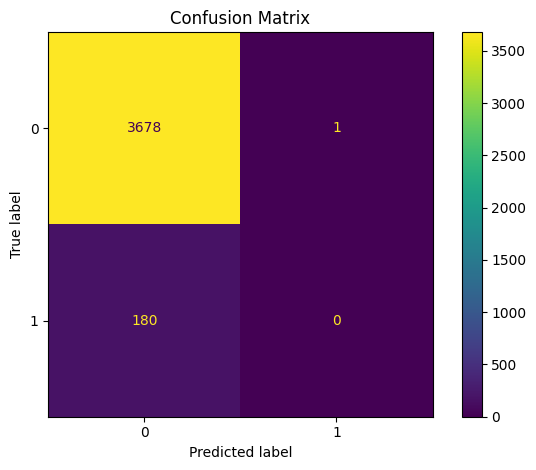

{'fit_time': array([0.19182086, 0.116575  , 0.17311621, 0.12424207, 0.3026278 ]),
 'score_time': array([0.0038321 , 0.00414205, 0.00501299, 0.00411797, 0.00416708]),
 'test_score': array([0.95238095, 0.95238095, 0.95238095, 0.95236552, 0.95236552]),
 'train_score': array([0.95245424, 0.95237324, 0.95253523, 0.9523771 , 0.95302503])}

In [ ]:
model_hgbc.fit(X_train, y_train)
pred = model_hgbc.predict(X_test)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cross_validate(model_hgbc, X, y, return_train_score=True)


#https://scikit-learn.org/stable/modules/ensemble.html#interpretation-with-feature-importance

In [ ]:


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_columns),
        ("num", numeric_pipeline, num_cols),
    ],
    remainder="passthrough"
)

# 3) Model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
cross_validate(clf, X, y, return_train_score=True)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

scores = cross_validate(
    clf, X, y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    return_train_score=True
)
scores

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

oof_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")

ConfusionMatrixDisplay.from_predictions(y, oof_pred, values_format="d")
plt.title("Out-of-fold Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()